In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install lightfm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 5.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp311-cp311-linux_x86_64.whl size=829228 sha256=4f58b2f5399fe3b4ef4850225d2ff9543c7bf97619e583599228ab111b000a93
  Stored in directory: /root/.cache/pip/wheels/b9/0d/8a/0729d2e6e3ca2a898ba55201f905da7db3f838a33df5b3fcdd
Successfully built lightfm


# **Data Overview**


*
ratings.csv — user ratings (user_id, book_id, rating, timestamp)

*
to_read.csv — book IDs users mark as “want to read”

*
Possibly tags.csv and book_tags.csv (mapping tags to books)

*
Maybe ratings.csv — the main user–book rating table

*
Other auxiliary files (like series, similar_books, etc., depending on the version)

In [3]:
booktags = pd.read_csv("/kaggle/input/goodbooks-10k/book_tags.csv")
books = pd.read_csv("/kaggle/input/goodbooks-10k/books.csv")
rating = pd.read_csv("/kaggle/input/goodbooks-10k/ratings.csv")
tags = pd.read_csv("/kaggle/input/goodbooks-10k/tags.csv")
toread = pd.read_csv("/kaggle/input/goodbooks-10k/to_read.csv")

In [4]:
# Check shapes
print("Books:", books.shape)
print("Ratings:", rating.shape)
print("Tags:", tags.shape)
print("Book_tags:", booktags.shape)
print("To_read:", toread.shape)

Books: (10000, 23)
Ratings: (981756, 3)
Tags: (34252, 2)
Book_tags: (999912, 3)
To_read: (912705, 2)


In [5]:
# Column names
print("\nBooks columns:", books.columns.tolist())
print("Ratings columns:", rating.columns.tolist())
print("Tags columns:", tags.columns.tolist())
print("Book_tags columns:", booktags.columns.tolist())
print("To_read columns:", toread.columns.tolist())


Books columns: ['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn', 'isbn13', 'authors', 'original_publication_year', 'original_title', 'title', 'language_code', 'average_rating', 'ratings_count', 'work_ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url', 'small_image_url']
Ratings columns: ['book_id', 'user_id', 'rating']
Tags columns: ['tag_id', 'tag_name']
Book_tags columns: ['goodreads_book_id', 'tag_id', 'count']
To_read columns: ['user_id', 'book_id']


# **EDA**

In [6]:
#Basic Info
print("Books info:")
print(books.info())
print("\nRatings info:")
print(rating.info())

Books info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10000 non-null  int64  
 1   book_id                    10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 no

In [7]:
# Missing values
print("\nMissing values in Books:")
print(books.isnull().sum())

print("\nMissing values in Ratings:")
print(rating.isnull().sum())

print("\nMissing values in Tags:")
print(tags.isnull().sum())

print("\nMissing values in Book_tags:")
print(booktags.isnull().sum())

print("\nMissing values in To_read:")
print(toread.isnull().sum())


Missing values in Books:
id                              0
book_id                         0
best_book_id                    0
work_id                         0
books_count                     0
isbn                          700
isbn13                        585
authors                         0
original_publication_year      21
original_title                585
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
image_url                       0
small_image_url                 0
dtype: int64

Missing values in Ratings:
book_id    0
user_id    0
rating     0
dtype: int64

Missing values in Tags:
tag_id      0
tag_name    0
dtype: int64

Missing values in Book_tags:
goo

In [8]:
#Duplicate check 
print("\nDuplicate rows in Books:", books.duplicated().sum())
print("Duplicate rows in Ratings:", rating.duplicated().sum())
print("Duplicate rows in Tags:", tags.duplicated().sum())
print("Duplicate rows in Book_tags:", booktags.duplicated().sum())
print("Duplicate rows in To_read:", toread.duplicated().sum())



Duplicate rows in Books: 0
Duplicate rows in Ratings: 1644
Duplicate rows in Tags: 0
Duplicate rows in Book_tags: 6
Duplicate rows in To_read: 0


In [9]:
#Ratings distribution
print("\nRatings value counts:")
print(rating['rating'].value_counts())


Ratings value counts:
rating
4    357366
5    292961
3    248623
2     63231
1     19575
Name: count, dtype: int64


In [10]:
# Average rating per user/book
print("\nAverage ratings per user:", rating.groupby('user_id')['rating'].count().mean())
print("Average ratings per book:", rating.groupby('book_id')['rating'].count().mean())


Average ratings per user: 18.376684636118597
Average ratings per book: 98.1756


# **Cleaning & Preprocessing**

**Handle missings and duplicates**

In [11]:
# Handle Dupicates
rating = rating.drop_duplicates()
booktags = booktags.drop_duplicates()

# Handle missing values in Books 
# Fill missing publication years with median
median_year = books['original_publication_year'].median()
books['original_publication_year'] = books['original_publication_year'].fillna(median_year)

# Fill missing language_code with "unknown"
books['language_code'] = books['language_code'].fillna("unknown")

books.drop(columns=["isbn", "isbn13", "original_title"], inplace=True)


**Filtering / trimming**

In [12]:
# Minimum thresholds
min_user_ratings = 5
min_book_ratings = 5

# Filter users with at least min_user_ratings
user_counts = rating['user_id'].value_counts()
rating = rating[rating['user_id'].isin(user_counts[user_counts >= min_user_ratings].index)]

# Filter books with at least min_book_ratings
book_counts = rating['book_id'].value_counts()
rating = rating[rating['book_id'].isin(book_counts[book_counts >= min_book_ratings].index)]

print("After filtering:")
print("Number of users:", rating['user_id'].nunique())
print("Number of books:", rating['book_id'].nunique())
print("Shape:", rating.shape)


After filtering:
Number of users: 35673
Number of books: 10000
Shape: (931255, 3)


**Scaling**

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize 'average_rating', 'ratings_count', 'text_reviews_count', 'original_publication_year'
books[['average_rating_norm', 'ratings_count_norm', 
       'text_reviews_count_norm', 'pub_year_norm']] = scaler.fit_transform(
    books[['average_rating', 'ratings_count', 
           'work_text_reviews_count', 'original_publication_year']].fillna(0)
)


**Encoding**

In [14]:
# Merge book_tags with tags
book_tags_merged = booktags.merge(tags, on="tag_id")

# Count most common tags
top_tags = book_tags_merged['tag_name'].value_counts().head(500).index

# Filter only top tags
book_tags_filtered = book_tags_merged[book_tags_merged['tag_name'].isin(top_tags)]

# Create multi-hot encoding
book_tag_matrix = (book_tags_filtered
                   .groupby(['goodreads_book_id', 'tag_name'])['count']
                   .sum()
                   .unstack(fill_value=0))

# Normalize tag counts (0-1)
book_tag_matrix = book_tag_matrix.apply(lambda x: x / x.max(), axis=0)


In [15]:
book_features = books[['book_id', 'title', 
                       'average_rating_norm', 'ratings_count_norm',
                       'text_reviews_count_norm', 'pub_year_norm']]

# Join with tag matrix
book_features = book_features.merge(book_tag_matrix, 
                                    left_on='book_id', 
                                    right_index=True, 
                                    how='left').fillna(0)


# **Visuallization**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


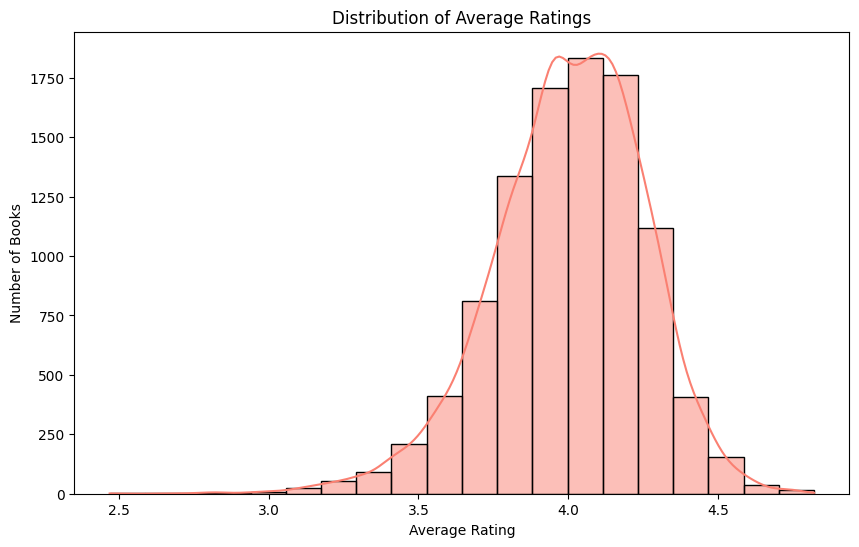

In [16]:
# Distribution of average ratings
plt.figure(figsize=(10, 6))
sns.histplot(books['average_rating'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Books')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


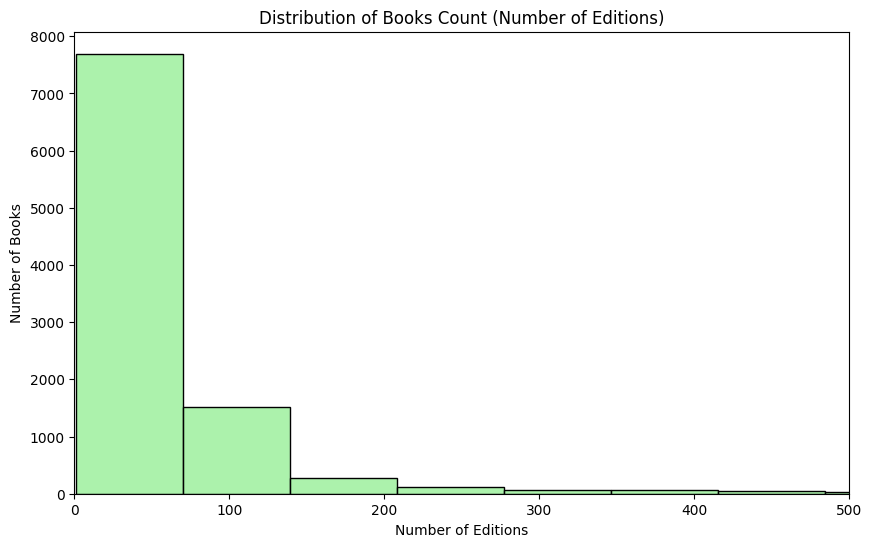

In [17]:
# Distribution of books count (number of editions)
plt.figure(figsize=(10, 6))
sns.histplot(books['books_count'], bins=50, kde=False, color='lightgreen')
plt.title('Distribution of Books Count (Number of Editions)')
plt.xlabel('Number of Editions')
plt.ylabel('Number of Books')
plt.xlim(0, 500)
plt.show()

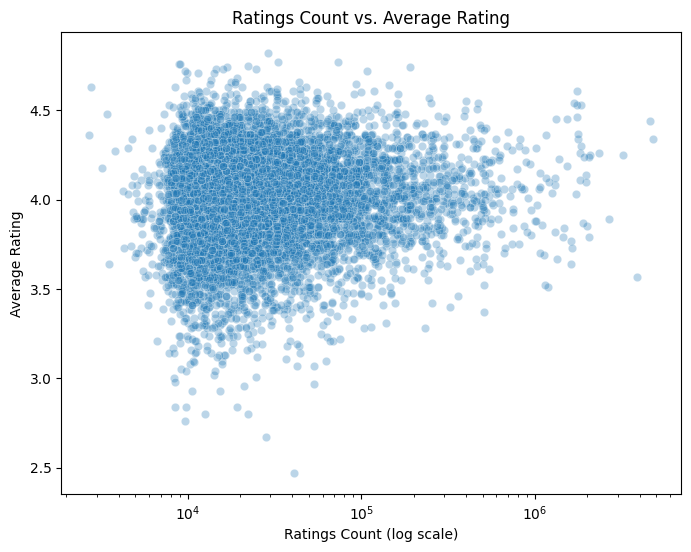

Correlation between ratings_count and average_rating: 0.045


In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="ratings_count", y="average_rating", data=books, alpha=0.3)
plt.xscale("log")  # log scale for readability
plt.title("Ratings Count vs. Average Rating")
plt.xlabel("Ratings Count (log scale)")
plt.ylabel("Average Rating")
plt.show()

# Correlation coefficient
corr = books['ratings_count'].corr(books['average_rating'])
print("Correlation between ratings_count and average_rating:", round(corr, 3))


The scatter plot shows the correlation between the number of ratings a book receives and its average rating. The x-axis (ratings count) is on a logarithmic scale for better visualization. Despite the wide range of ratings counts, the average ratings cluster around 3.5 to 4.5, as previously noted. There is not necessarily a strong correlation between a book's popularity, as measured by the number of ratings, and its average rating. Books with a high number of ratings can have a wide range of average ratings. However, there is a slight concentration of books with higher ratings counts also having moderately high average ratings.



In [19]:
ratings = rating.drop_duplicates(subset=["user_id", "book_id"], keep="last")

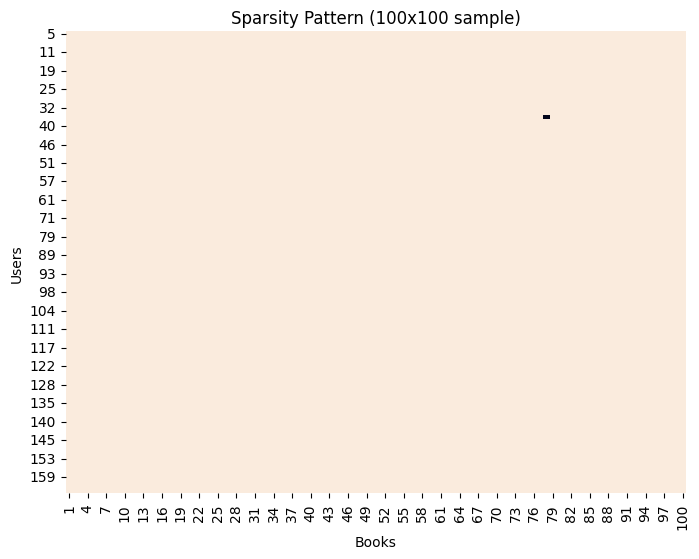

In [20]:
# Sparsity check (sample user-item matrix)
import numpy as np
sample = ratings.pivot(index="user_id", columns="book_id", values="rating")
sample = sample.iloc[:100, :100]  # small sample

plt.figure(figsize=(8,6))
sns.heatmap(sample.isnull(), cbar=False)
plt.title("Sparsity Pattern (100x100 sample)")
plt.xlabel("Books")
plt.ylabel("Users")
plt.show()

In [21]:
#Quantity Sparsity 
n_users = rating['user_id'].nunique()
n_books = rating['book_id'].nunique()
n_ratings = len(rating)

sparsity = 1 - (n_ratings / (n_users * n_books))
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")


Sparsity: 0.9974 (99.74%)


The user–item matrix is highly sparse (99.82%), meaning that only 0.18% of all possible user–book interactions are observed. This reflects real-world behavior, where users typically rate a small subset of books. Such sparsity poses challenges for collaborative filtering and motivates data preprocessing steps like filtering rare users/books and enriching models with content-based features.

# **Modeling**

**Data split**

In [22]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(rating, test_size=0.2, random_state=42)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (745004, 3)
Test shape: (186251, 3)


**KNN**

In [39]:
from sklearn.neighbors import NearestNeighbors

In [40]:
feature_cols = ['average_rating_norm', 'ratings_count_norm', 'pub_year_norm']
features_df = books[feature_cols]

In [41]:
knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(features_df)


NearestNeighbors(metric='cosine', n_neighbors=6)

In [42]:
def recommend_books(book_id, knn_model, features, books, top_n=5):
    idx = books.index[books['book_id'] == book_id][0]  # find index of book
    distances, indices = knn_model.kneighbors(features.iloc[idx:idx+1], n_neighbors=top_n+1)
    recommended = books.iloc[indices.flatten()[1:]]  # skip the book itself
    return recommended[['book_id', 'title']]

In [43]:
book_id = 3  # example book_id
recommendations = recommend_books(book_id, knn, features_df , books, 5)
print(recommendations[['book_id', 'title']])


    book_id                                    title
0   2767052  The Hunger Games (The Hunger Games, #1)
3      2657                    To Kill a Mockingbird
2     41865                  Twilight (Twilight, #1)
4      4671                         The Great Gatsby
5  11870085                   The Fault in Our Stars


In [44]:
import pickle

# Create a simplified version of books for the app
books_for_app = book_features.copy()

# If you have a 'tags_str' column, make sure it's included (for CountVectorizer)
# Example: concatenate top tags for each book
book_tags_merged['tag_name'] = book_tags_merged['tag_name'].astype(str)
tags_str_df = book_tags_merged.groupby('goodreads_book_id')['tag_name'].apply(lambda x: ' '.join(x)).reset_index()
books_for_app = books_for_app.merge(tags_str_df, left_on='book_id', right_on='goodreads_book_id', how='left')
books_for_app.rename(columns={'tag_name':'tags_str'}, inplace=True)
books_for_app.fillna('', inplace=True)

# Save the DataFrame to pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(books_for_app.to_dict(orient='records'), f)
